In [22]:
import tensorflow as tf
import keras
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split,KFold
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import time

In [2]:
plt.rcParams['font.sans-serif'] = ['Simhei']   #用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] =  False    #用来正常显示负号

import os
import time
pd.set_option('display.max_columns', 999)    #设置数据展示的最大列数和最大行数
pd.set_option('display.max_rows', 500)

In [3]:
df= pd.read_csv('data-14-01_datawash.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41464 entries, 0 to 41463
Columns: 237 entries, COPAY_PCT to PROV_LEVEL_非医保
dtypes: float64(8), int64(229)
memory usage: 75.0 MB


In [5]:
df.describe()

,COPAY_PCT,CWF_AMT_DAY,INVOICE_CNT,POLICY_CNT,ORG_PRES_AMT_VALUE,APP_AMT,REJECTED_AMT,SUB_AMT,CL_SOCIAL_PAY_AMT,CL_THIRD_PARTY_PAY_AMT,CL_OWNER_PAY_AMT,CL_SELF_CAT_PAY_AMT,FRAUD,T190,R540,R100,W270,R270,W070,R130,W105,M118,M101,R605,W290,W410,W120,R010,M121,M060,M009,W230,M116,W360,R140,R520,M002,M109,T250,W310,M144,M123,R180,W055,W200,M143,W220,W380,T450,W250,W390,R260,W190,W050,R682,M117,W090,W057,T460,T180,M110,W020,W180,W260,R542,M119,R030,M113,W010,W100,M107,W210,W040,M114,R680,R600,R040,R060,M004,R658,M029,M120,R625,W400,R170,T420,M149,R610,W340,W280,R530,M111,W080,M155,W056,BEN_TYPE_DT,BEN_TYPE_GG-IP,BEN_TYPE_GG-OP,BEN_TYPE_IP,BEN_TYPE_IPCASB,BEN_TYPE_JW-OP,BEN_TYPE_MA,BEN_TYPE_MDB,BEN_TYPE_MEMR,BEN_TYPE_MT,BEN_TYPE_OP,BEN_TYPE_PA,BEN_TYPE_VS,BEN_TYPE_YW-IP,BEN_TYPE_YW-OP,MBR_TYPE_Applicant,MBR_TYPE_Child,MBR_TYPE_Parents,MBR_TYPE_Spouse,BEN_HEAD_100PF,BEN_HEAD_100PF-JCF,BEN_HEAD_100PF-YPF,BEN_HEAD_ACUP,BEN_HEAD_BTAT,BEN_HEAD_CASB,BEN_HEAD_CASB-ZJ,BEN_HEAD_CC-CLF,BEN_HEAD_CC-GHF,BEN_HEAD_CC-JCF,BEN_HEAD_CC-MZSS,BEN_HEAD_CC-YPF,BEN_HEAD_CC-ZLF,BEN_HEAD_CR,BEN_HEAD_ER,BEN_HEAD_EXC,BEN_HEAD_EXLS,BEN_HEAD_EXZL,BEN_HEAD_F-CJF,BEN_HEAD_F-CLF,BEN_HEAD_F-CWF,BEN_HEAD_F-GHF,BEN_HEAD_F-JCF,BEN_HEAD_F-MZSS,BEN_HEAD_F-YPF,BEN_HEAD_F-ZFJC,BEN_HEAD_F-ZFYP,BEN_HEAD_F-ZLF,BEN_HEAD_F-ZYF,BEN_HEAD_HERB,BEN_HEAD_HVIS,BEN_HEAD_JW-GHF,BEN_HEAD_JW-YPF,BEN_HEAD_JZF-JCF,BEN_HEAD_JZF-YPF,BEN_HEAD_JZF-ZFYP,BEN_HEAD_JZS-GHF,BEN_HEAD_JZS-JCF,BEN_HEAD_JZS-YPF,BEN_HEAD_LAB,BEN_HEAD_LAMB,BEN_HEAD_LC,BEN_HEAD_LENS,BEN_HEAD_MF,BEN_HEAD_MISC,BEN_HEAD_MND,BEN_HEAD_MSD,BEN_HEAD_MT-CLF,BEN_HEAD_MT-GHF,BEN_HEAD_MT-JCF,BEN_HEAD_MT-MZSS,BEN_HEAD_MT-YPF,BEN_HEAD_MT-ZLF,BEN_HEAD_MTR,BEN_HEAD_MZGKYC,BEN_HEAD_MZY,BEN_HEAD_NF,BEN_HEAD_NF-JCF,BEN_HEAD_NF-YPF,BEN_HEAD_NS-GHF,BEN_HEAD_NS-JCF,BEN_HEAD_NS-YPF,BEN_HEAD_NS-ZFYP,BEN_HEAD_NS-ZLF,BEN_HEAD_O1K-MZY,BEN_HEAD_O1K-ZFYP,BEN_HEAD_O1K-ZYF,BEN_HEAD_OPR,BEN_HEAD_OV,BEN_HEAD_PS,BEN_HEAD_RB,BEN_HEAD_RH-CLF,BEN_HEAD_RH-GHF,BEN_HEAD_RH-JCF,BEN_HEAD_RH-OV,BEN_HEAD_RH-PS,BEN_HEAD_RH-YPF,BEN_HEAD_RH-ZLF,BEN_HEAD_RX,BEN_HEAD_S-CJF,BEN_HEAD_S-CLF,BEN_HEAD_S-FMF,BEN_HEAD_S-GHF,BEN_HEAD_S-JCF,BEN_HEAD_S-MT,BEN_HEAD_S-MZSS,BEN_HEAD_S-OV,BEN_HEAD_S-PS,BEN_HEAD_S-YPF,BEN_HEAD_S-ZFYP,BEN_HEAD_S-ZLF,BEN_HEAD_S-ZYF,BEN_HEAD_SC1,BEN_HEAD_SH1,BEN_HEAD_SPFRM,BEN_HEAD_SPLEN,BEN_HEAD_THER,BEN_HEAD_TRTC,BEN_HEAD_TX-GHF,BEN_HEAD_TX-JCF,BEN_HEAD_TX-MZSS,BEN_HEAD_TX-YPF,BEN_HEAD_TX-ZLF,BEN_HEAD_WSS-YPF,BEN_HEAD_YJ-GHF,BEN_HEAD_YJ-JCF,BEN_HEAD_YJ-MZSS,BEN_HEAD_YJ-YPF,BEN_HEAD_YJ-ZLF,BEN_HEAD_ZY-CWF,BEN_HEAD_ZY-LC,BEN_HEAD_ZY-YPF,BEN_HEAD_ZY-ZFYP,BEN_HEAD_ZYF,PROV_LEVEL_一级,PROV_LEVEL_三级,PROV_LEVEL_二级,PROV_LEVEL_医保,PROV_LEVEL_卫生所,PROV_LEVEL_未知,PROV_LEVEL_未评级,PROV_LEVEL_特需,PROV_LEVEL_非医保
count,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,41464.000000,414

In [6]:
# APP_AMT PAY_AMT REJECTED_AMT
df.drop(columns=['APP_AMT', 'REJECTED_AMT'],inplace= True)


In [7]:
# FRAUD 列为目标变量
df['FRAUD'].value_counts()
# 0:正常 1:欺诈

FRAUD
0    38032
1     3432
Name: count, dtype: int64

In [8]:
# 分离特征和标签
X = df.drop(columns=['FRAUD'])
y = df['FRAUD']
# 训练集和测试集划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41464 entries, 0 to 41463
Columns: 234 entries, COPAY_PCT to PROV_LEVEL_非医保
dtypes: float64(6), int64(228)
memory usage: 74.0 MB


In [84]:
# svm
from sklearn.svm import SVC
# 创建SVM模型
model = SVC(kernel='linear', C=1.0, random_state=42)
# 训练模型
model.fit(X_train, y_train)
# 预测测试集
y_pred = model.predict(X_test)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))




Confusion Matrix:
[[7592    7]
 [  45  649]]
Classification Report:
              precision    recall  f1-score   support

           0   0.994108  0.999079  0.996587      7599
           1   0.989329  0.935159  0.961481       694

    accuracy                       0.993730      8293
   macro avg   0.991718  0.967119  0.979034      8293
weighted avg   0.993708  0.993730  0.993649      8293



In [136]:
# knn
from sklearn.neighbors import KNeighborsClassifier
# 创建KNN模型
model = KNeighborsClassifier(n_neighbors=2, metric='euclidean')
# 训练模型
model.fit(X_train, y_train)
# 预测测试集
y_pred = model.predict(X_test)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))

Confusion Matrix:
[[7587   12]
 [ 192  502]]
Classification Report:
              precision    recall  f1-score   support

           0   0.975318  0.998421  0.986734      7599
           1   0.976654  0.723343  0.831126       694

    accuracy                       0.975401      8293
   macro avg   0.975986  0.860882  0.908930      8293
weighted avg   0.975430  0.975401  0.973712      8293



In [115]:
# random forest
from sklearn.ensemble import RandomForestClassifier
# 创建随机森林模型
model = RandomForestClassifier(n_estimators=120, random_state=42)
model.fit(X_train, y_train)
# 预测
y_pred = model.predict(X_test)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))


Confusion Matrix:
[[7585   14]
 [  24  670]]
Classification Report:
              precision    recall  f1-score   support

           0   0.996846  0.998158  0.997501      7599
           1   0.979532  0.965418  0.972424       694

    accuracy                       0.995418      8293
   macro avg   0.988189  0.981788  0.984963      8293
weighted avg   0.995397  0.995418  0.995403      8293



In [ ]:
# 找出错误分类的样本
misclassified_samples = X_test[y_test != y_pred]
print("Misclassified samples:")
print(misclassified_samples.T)


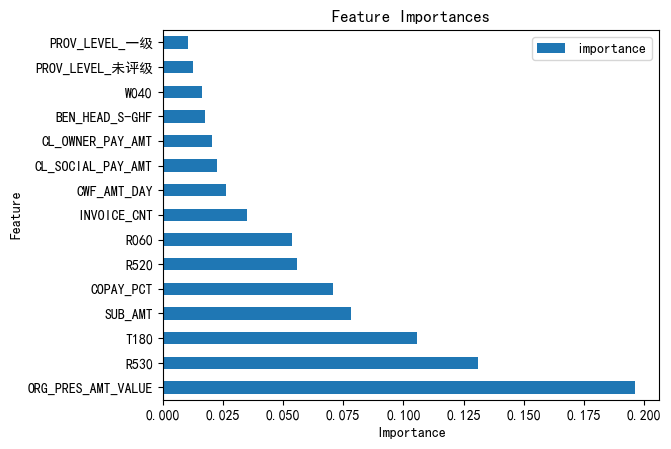

In [117]:

# 画出特征重要性图
importances = pd.DataFrame({'feature':X.columns,'importance':np.round(model.feature_importances_,6)})
importances = importances.sort_values('importance',ascending=False).set_index('feature')
importances.head(15).plot(kind='barh')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

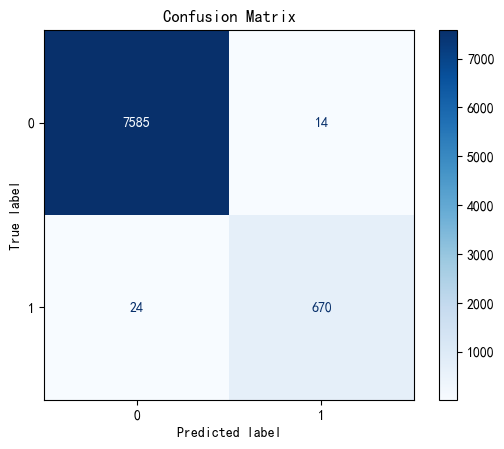

In [118]:
# 画出混淆矩阵
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
# 预测
y_pred = model.predict(X_test)
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [56]:
# xgboost
import xgboost as xgb
from xgboost import XGBClassifier
# 创建XGBoost模型
model = XGBClassifier(n_estimators=120, max_depth=14, min_child_weight=1)
# 训练模型
model.fit(X_train, y_train)
# 预测测试集
y_pred = model.predict(X_test)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))


Confusion Matrix:
[[7578   21]
 [  18  676]]
Classification Report:
              precision    recall  f1-score   support

           0   0.997630  0.997236  0.997433      7599
           1   0.969871  0.974063  0.971963       694

    accuracy                       0.995297      8293
   macro avg   0.983751  0.985650  0.984698      8293
weighted avg   0.995307  0.995297  0.995302      8293



In [24]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
model = XGBClassifier()
kfold = StratifiedKFold(n_splits=10)
results = cross_val_score(model, X_train, y_train, cv=kfold)
print("Accuracy: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

Accuracy: 99.46% (0.11%)


In [40]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
#Need to research
#research_one: n_epoch
#research_one: max_depth
param_test1 = {
    'n_estimators': [10,20,30,40,50,100,120,140,200],
    'min_child_weight': [1, 2, 3, 4, 5,6,7],
    'max_depth':[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,30,40,50],
    }

xgb_res = RandomizedSearchCV(estimator = XGBClassifier(), 
                       param_distributions=param_test1,
                       n_iter=100)

xgb_res.fit(X_train, y_train)

RandomizedSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=No...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=100,
                   param_distributions={'max_depth': [3, 4, 5, 6, 7, 8, 9, 10,
                                                      11, 12, 13, 14, 15, 16,
                                                      17, 18, 19, 20, 30, 40,
                                                      50],
                                        'min_child_weight': [1, 2, 3, 4, 5, 6,
                                                             7],
                                        'n_estimators': [10, 20, 30, 40, 50,
                                                         100, 120, 140, 200]})

In [41]:
print('max_depth_min_child_weight')
# print('gsearch1.grid_scores_', xgb_res.cv_results_)
print('gsearch1.best_params_', xgb_res.best_params_)
print('gsearch1.best_score_', xgb_res.best_score_)

max_depth_min_child_weight
gsearch1.best_params_ {'n_estimators': 120, 'min_child_weight': 1, 'max_depth': 14}
gsearch1.best_score_ 0.9945132914657859


In [24]:
# MLP
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation
from keras.layers import LeakyReLU
from keras.layers import BatchNormalization


In [119]:
model = Sequential()
model.add(Dense(128, input_shape=(234,)))
model.add(BatchNormalization())
model.add(Dropout(rate=0.5))
model.add(LeakyReLU(negative_slope=0.05))
model.add(BatchNormalization())
model.add(Dropout(rate=0.5))
model.add(Dense(units=64))
model.add(LeakyReLU(negative_slope=0.05))
model.add(BatchNormalization())
model.add(Dropout(rate=0.5))
model.add(Dense(units=1,activation='sigmoid'))


c:\Users\12132\Desktop\Project_hemeow\pyvenv\TFvenv\Lib\site-packages\keras\src\layers\core\dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [120]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │        30,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,681 (155.00 KB)

 Trainable params: 39,041 (152.50 KB)

 Non-trainable params: 640 (2.50 KB)

In [121]:
model.compile(loss='binary_crossentropy', 
              optimizer='adam', metrics=['accuracy'])

In [122]:
train_history =model.fit(x=X_train, 
                         y=y_train, 
                         validation_split=0.2, 
                         epochs=100, 
                         batch_size=100,verbose=2)

Epoch 1/100
266/266 - 2s - 7ms/step - accuracy: 0.7897 - loss: 0.5049 - val_accuracy: 0.9466 - val_loss: 0.1783
Epoch 2/100
266/266 - 0s - 2ms/step - accuracy: 0.9534 - loss: 0.1663 - val_accuracy: 0.9857 - val_loss: 0.0500
Epoch 3/100
266/266 - 0s - 2ms/step - accuracy: 0.9740 - loss: 0.0892 - val_accuracy: 0.9879 - val_loss: 0.0412
Epoch 4/100
266/266 - 0s - 2ms/step - accuracy: 0.9785 - loss: 0.0722 - val_accuracy: 0.9879 - val_loss: 0.0390
Epoch 5/100
266/266 - 0s - 2ms/step - accuracy: 0.9821 - loss: 0.0623 - val_accuracy: 0.9891 - val_loss: 0.0313
Epoch 6/100
266/266 - 0s - 2ms/step - accuracy: 0.9844 - loss: 0.0545 - val_accuracy: 0.9898 - val_loss: 0.0263
Epoch 7/100
266/266 - 0s - 2ms/step - accuracy: 0.9858 - loss: 0.0490 - val_accuracy: 0.9917 - val_loss: 0.0257
Epoch 8/100
266/266 - 0s - 2ms/step - accuracy: 0.9858 - loss: 0.0456 - val_accuracy: 0.9907 - val_loss: 0.0261
Epoch 9/100
266/266 - 0s - 2ms/step - accuracy: 0.9872 - loss: 0.0418 - val_accuracy: 0.9920 - val_loss:

In [123]:
import matplotlib.pyplot as plt

def visu_train_history(train_history,train_metric,validation_metric):
    plt.plot(train_history.history[train_metric])
    plt.plot(train_history.history[validation_metric])
    plt.title('Train History')
    plt.ylabel(train_metric)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

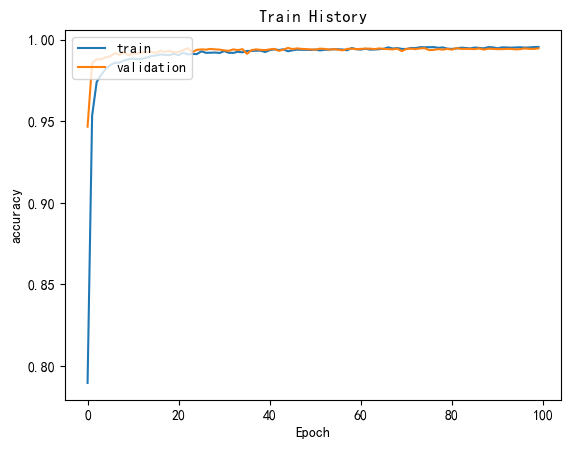

In [124]:
visu_train_history(train_history,'accuracy','val_accuracy')

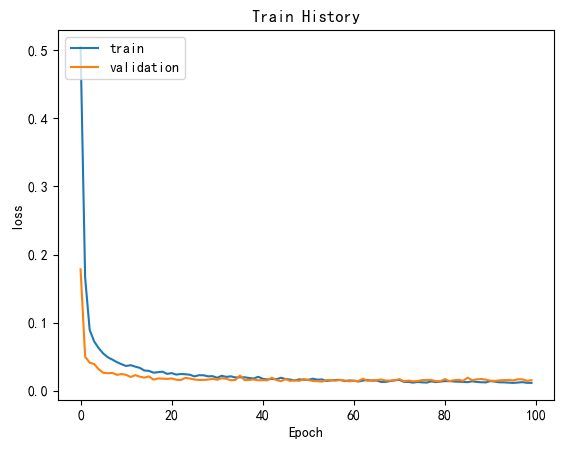

In [125]:
visu_train_history(train_history,'loss','val_loss')

In [126]:
evaluate_result = model.evaluate(x=X_test, 
                        y=y_test)

260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.9946 - loss: 0.0223


In [127]:
evaluate_result

[0.021100103855133057, 0.9946942925453186]

In [128]:
y_pred = model.predict(X_test)
y_pred=[y_pred>=0.5]
y_pred=y_pred[0].astype(int)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))

260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step
Confusion Matrix:
[[7579   20]
 [  24  670]]
Classification Report:
              precision    recall  f1-score   support

           0   0.996843  0.997368  0.997106      7599
           1   0.971014  0.965418  0.968208       694

    accuracy                       0.994694      8293
   macro avg   0.983929  0.981393  0.982657      8293
weighted avg   0.994682  0.994694  0.994687      8293

